## gCRL-VAE applied on the Norman dataset

- Load Norman adata, formatted for gCRL-VAE (adata.X is norm. logp1 transformed, important info added to adata.var and adata.obs)
- Compute eigengenes
- Train gCRL-VAE
- Validate

In [1]:
# ensuring all packages are reloaded each time I run a cell
%load_ext autoreload
%autoreload 2

In [2]:
# importing
import numpy as np
import pandas as pd
import scanpy as sc
from gcrl.training.train_gcrl_vae import train_gcrl_vae, analyze_dataset_and_suggest_config
from gcrl.grn.eigengenes import compute_eigengenes

In [3]:
# loading data
adata = sc.read_h5ad("../../data/real/Norman2019/Norman2019_processed.h5ad")
adata

AnnData object with n_obs × n_vars = 24999 × 5000
    obs: 'guide_identity', 'read_count', 'UMI_count', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_ids', 'guide_merged', 'split', 'batch', 'condition', 'cell_type', 'dose_val', 'control', 'drug_dose_name', 'cov_drug_dose_name', 'intervention', 'set'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl', 'kind', 'community'
    uns: 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'rank_genes_groups_cov', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
# computing eigengenes
compute_eigengenes(adata)
adata

AnnData object with n_obs × n_vars = 24999 × 5000
    obs: 'guide_identity', 'read_count', 'UMI_count', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_ids', 'guide_merged', 'split', 'batch', 'condition', 'cell_type', 'dose_val', 'control', 'drug_dose_name', 'cov_drug_dose_name', 'intervention', 'set'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl', 'kind', 'community'
    uns: 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'rank_genes_groups_cov', 'umap', 'X_comm_eig_comm_ids', 'X_comm_eig_global_index', 'comm_eig_meta'
    obsm: 'X_pca', 'X_umap', 'X_comm_eig'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Auto-Configuration

Use intelligent auto-configuration to analyze dataset and suggest optimal parameters.
This examines:
- Number of control cells per cell type
- Number of interventions  
- Number of latent factors/communities
- Dataset size

The system will automatically select:
- Batch size (based on controls per cell-type)
- Number of epochs (based on dataset size)
- Learning rate (based on batch size)
- Loss weights (based on dataset characteristics)

In [5]:
# Auto-configuration (uses proven v1 strategy)
# Analyze dataset and suggest optimal configuration
cfg = analyze_dataset_and_suggest_config(
    adata, 
    outdir="../../results/real/Norman2019/VAE",
    verbose=True
)

# The auto-config now uses the v1 strategy (proven to work):
# - alpha_rec = 1.0 (balanced reconstruction weight)
# - beta_kld_max = 0.01 (gentle KL regularization)  
# - lambda_mcc = 0.75 (strong alignment - critical!)
# 
# For Norman2019, this achieves:
# - Reconstruction: ~0.197 (excellent)
# - Alignment: ~-0.992 (near-perfect)
# - KL Divergence: ~0.640 (controlled)

# You can still override specific parameters if needed:
# cfg.epochs = 100  # Override epochs
# cfg.alpha_rec = 1.5  # Slightly stronger reconstruction (only if needed)
# etc.

print("\n✓ Configuration ready!")


Dataset Analysis for gCRL-VAE Configuration

📊 Dataset Size:
  - Total cells: 24,999
  - Training cells: 23,296 (93.2%)
  - Control cells (training): 8,907
  - Intervened cells (training): 14,389

🧬 Gene Information:
  - Total genes: 5,000
  - Transcription factors (TFs): 167
  - Target genes (TGs): 4833

🔬 Cell Types:
  - Number of cell types: 1
  - Controls per cell type: min=8907, mean=8907

🧪 Interventions:
  - Number of unique interventions: 26

🧠 Latent Structure:
  - TF communities: 6
  - Latent dimensions (p+1): 7

⚙️  Suggested Configuration:
  - GPU Memory: 21.2 GB available
    → Target usage: 35% (7.4 GB) for safe training
  - Batch size: 256 (GPU memory limited)
    → Ideal from dataset: 512
    → GPU memory allows: 256
    → Selected: 256 (conservative)
    → Estimated memory: 5.1 GB
  - Epochs: 50 (based on 8,907 control cells)
  - Learning rate: 0.002 (based on batch size)
  - Alpha Rec: 1.0 (based on 29.9× TF→gene expansion)
  - Beta KLD max: 0.01 (based on 8,907 cell

In [20]:
cfg.batch_size = 384  # Override batch size if needed
cfg.epochs = 150  # Override epochs if needed
print(cfg.batch_size)
print(cfg.epochs)

384
150


In [21]:
import torch
torch.cuda.empty_cache()

In [22]:
# Training gCRL-VAE
# NOTE: train_gcrl_vae will:
# 1. Display GPU information and confirm device usage
# 2. Apply per-cell-type z-scoring using training controls only
# 3. Train on controls only (reconstruction + eigengene alignment)
# 4. Validate against real interventions using MMD loss
# 5. Show progress bars for epochs and batches
# 6. Save training history to training_history.json

model, history = train_gcrl_vae(adata=adata, cfg=cfg)

print("\n✓ Training completed!")
print(f"Model saved to: {cfg.outdir}/norman_model.pt")
print(f"Training history: {cfg.outdir}/training_history.json")

# Alternative: Load pre-trained model
# import torch
# model = torch.load(cfg.outdir + '/norman_model.pt')
# adata = sc.read_h5ad(cfg.outdir + '/norman_post_training.h5ad')

gCRL-VAE Training Configuration
✓ GPU ENABLED: NVIDIA RTX A4500
  - GPU Memory: 21.16 GB
  - CUDA Version: 11.8
Device: cuda
[gCRL-VAE] Using TF-only input: 167 TFs (from 5000 total genes)


Training gCRL-VAE:   0%|          | 0/150 [00:00<?, ?epoch/s]

Epoch 1/150:   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 2/150:   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 3/150:   0%|          | 0/24 [00:00<?, ?batch/s]

...

Epoch 147/150:   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 148/150:   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 149/150:   0%|          | 0/24 [00:00<?, ?batch/s]

Epoch 150/150:   0%|          | 0/24 [00:00<?, ?batch/s]


✓ Training completed!
Model saved to: ../../results/real/Norman2019/VAE/norman_model.pt
Training history: ../../results/real/Norman2019/VAE/training_history.json


In [23]:
# Model architecture
# NOTE: With new gCRL-VAE implementation:
# - Encoder input: n_TFs only (not all genes)
# - Encoder architecture: [n_TFs -> 128 -> 2*(p+1)]
# - Decoder: Polynomial decoder (linear + quadratic terms, no hidden layers)
# - Decoder output: All genes (n_TFs + n_TGs)
print(f"Model: {model}")
print(f"\nLatent dimension (z_dim): {model.cfg.z_dim}")
print(f"Intervention dimension (c_dim): {model.cfg.c_dim}")
print(f"Input dimension: {model.cfg.input_dim} (TFs only)")
print(f"Output dimension: {model.cfg.output_dim} (all genes)")
if hasattr(model.cfg, 'ct_dim'):
    print(f"Cell-type dimension: {model.cfg.ct_dim}")
print(f"\nDAG causal matrix G shape: {model.G.shape}")
print(f"Intervention mapping: {model.cfg.intervention_mapping}")
print(f"Using polynomial decoder: {model.cfg.use_polynomial_decoder}")
model

Model: GCRLVAE(
  (encoder): Sequential(
    (0): Linear(in_features=167, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (fc_mu): Linear(in_features=128, out_features=7, bias=True)
  (fc_var): Linear(in_features=128, out_features=7, bias=True)
  (decoder_linear): Linear(in_features=7, out_features=5000, bias=True)
  (decoder_quadratic): Linear(in_features=49, out_features=5000, bias=True)
)

Latent dimension (z_dim): 7
Intervention dimension (c_dim): 20
Input dimension: 167 (TFs only)
Output dimension: 5000 (all genes)
Cell-type dimension: 0

DAG causal matrix G shape: torch.Size([7, 7])
Intervention mapping: hard
Using polynomial decoder: True


GCRLVAE(
  (encoder): Sequential(
    (0): Linear(in_features=167, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.1, inplace=True)
  )
  (fc_mu): Linear(in_features=128, out_features=7, bias=True)
  (fc_var): Linear(in_features=128, out_features=7, bias=True)
  (decoder_linear): Linear(in_features=7, out_features=5000, bias=True)
  (decoder_quadratic): Linear(in_features=49, out_features=5000, bias=True)
)

In [24]:
# Saving model and data
import torch
import os

os.makedirs(cfg.outdir, exist_ok=True)

# Save AnnData with preprocessed data
adata.write_h5ad(cfg.outdir + '/norman_post_training.h5ad')

# Save model using PyTorch (recommended over pickle)
torch.save(model.state_dict(), cfg.outdir + '/norman_model_state.pt')
torch.save(model, cfg.outdir + '/norman_model.pt')

# Save training history (already saved by train_gcrl_vae as training_history.json)
print(f"Model and data saved to {cfg.outdir}")

Model and data saved to ../../results/real/Norman2019/VAE


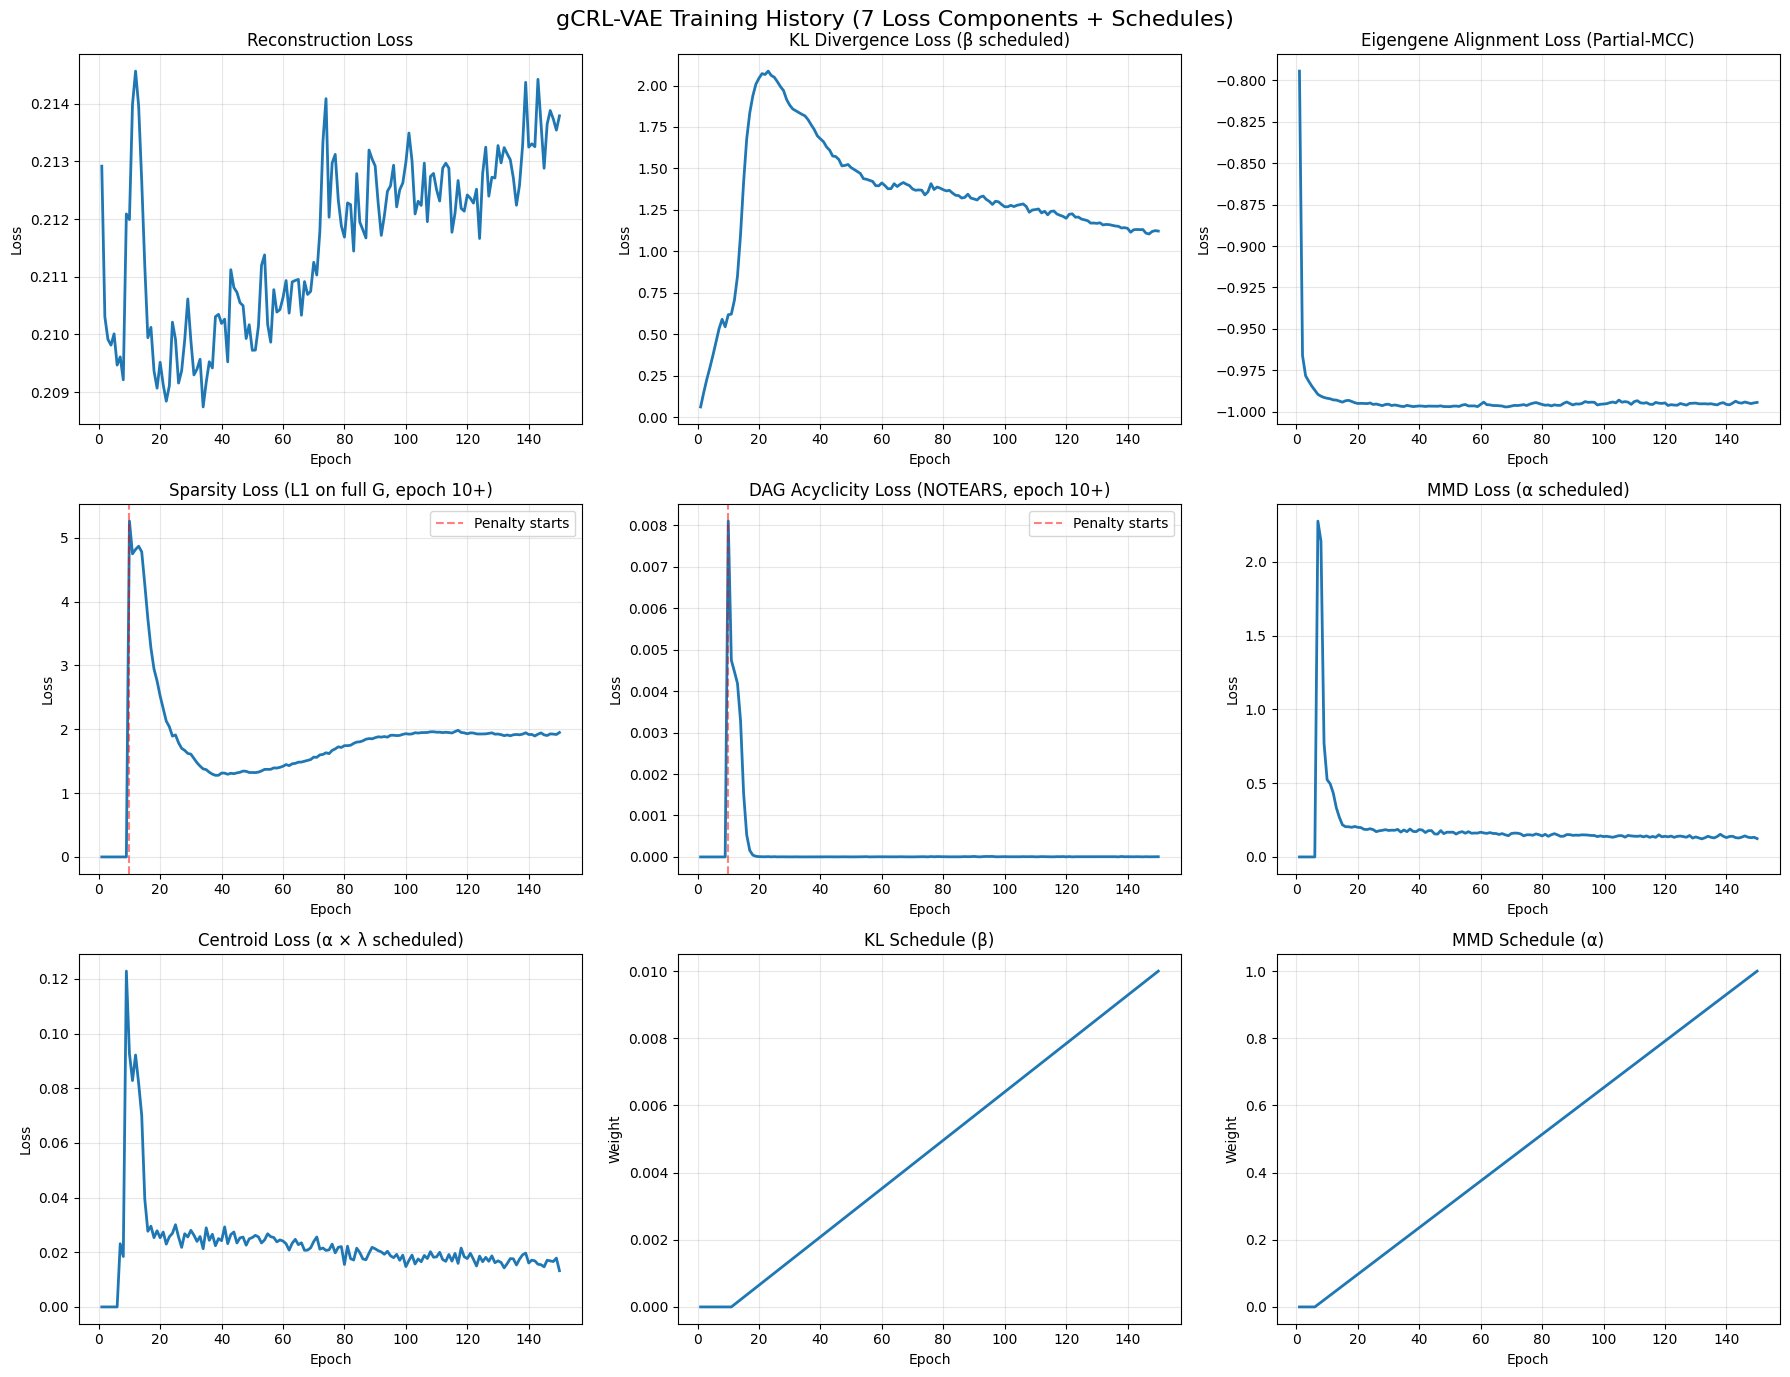

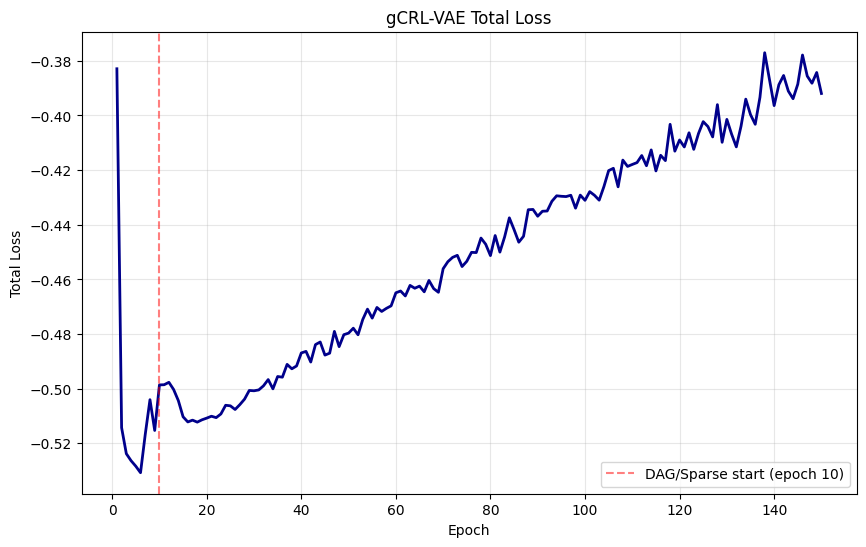


Final loss values (last epoch):
  Total Loss: -0.3919
  Reconstruction: 0.2138
  KL Divergence: 1.1221 (β=0.0100)
  Alignment (MCC): -0.9944
  Sparsity: 1.9495
  DAG Acyclicity: 0.0000
  MMD: 0.1243 (α=1.0000)
  Centroid: 0.0133

📊 New in this version:
  - DAG acyclicity constraint (NOTEARS) applied from epoch 10
  - Full G matrix learning (not restricted to upper-triangular)
  - Sparsity penalty on full G (10× weaker, starts epoch 10)
  - Model learns optimal causal ordering from data


In [25]:
# Visualize training history
import matplotlib.pyplot as plt
import json

# Load history (already saved by train_gcrl_vae)
with open(cfg.outdir + '/training_history.json', 'r') as f:
    history = json.load(f)

# Convert to DataFrame for easier plotting
history_df = pd.DataFrame(history)

# Plot all 7 loss components (updated with DAG loss)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('gCRL-VAE Training History (7 Loss Components + Schedules)', fontsize=16)

# Loss components to plot
components = [
    ('loss_rec', 'Reconstruction Loss', axes[0, 0]),
    ('loss_kld', 'KL Divergence Loss (β scheduled)', axes[0, 1]),
    ('loss_mcc', 'Eigengene Alignment Loss (Partial-MCC)', axes[0, 2]),
    ('loss_sparse', 'Sparsity Loss (L1 on full G, epoch 10+)', axes[1, 0]),
    ('loss_dag', 'DAG Acyclicity Loss (NOTEARS, epoch 10+)', axes[1, 1]),
    ('loss_mmd', 'MMD Loss (α scheduled)', axes[1, 2]),
    ('loss_centroid', 'Centroid Loss (α × λ scheduled)', axes[2, 0]),
    ('beta_kl', 'KL Schedule (β)', axes[2, 1]),
    ('alpha_mmd', 'MMD Schedule (α)', axes[2, 2])
]

for loss_key, title, ax in components:
    if loss_key in history_df.columns:
        ax.plot(history_df['epoch'], history_df[loss_key], linewidth=2)
        ax.set_xlabel('Epoch')
        if 'beta' in loss_key or 'alpha' in loss_key:
            ax.set_ylabel('Weight')
        else:
            ax.set_ylabel('Loss')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        
        # Highlight when DAG/Sparse penalties start (epoch 10)
        if loss_key in ['loss_dag', 'loss_sparse']:
            ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='Penalty starts')
            ax.legend()

plt.tight_layout()
plt.savefig(cfg.outdir + '/training_loss_components.png', dpi=150)
plt.show()

# Plot total loss
plt.figure(figsize=(10, 6))
plt.plot(history_df['epoch'], history_df['loss'], linewidth=2, color='darkblue')
plt.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='DAG/Sparse start (epoch 10)')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('gCRL-VAE Total Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(cfg.outdir + '/training_total_loss.png', dpi=150)
plt.show()

# Print final losses
print("\nFinal loss values (last epoch):")
final = history_df.iloc[-1]
print(f"  Total Loss: {final['loss']:.4f}")
print(f"  Reconstruction: {final['loss_rec']:.4f}")
print(f"  KL Divergence: {final['loss_kld']:.4f} (β={final['beta_kl']:.4f})")
print(f"  Alignment (MCC): {final['loss_mcc']:.4f}")
print(f"  Sparsity: {final['loss_sparse']:.4f}")
if 'loss_dag' in final:
    print(f"  DAG Acyclicity: {final['loss_dag']:.4f}")
print(f"  MMD: {final['loss_mmd']:.4f} (α={final['alpha_mmd']:.4f})")
print(f"  Centroid: {final['loss_centroid']:.4f}")

print("\n📊 New in this version:")
print("  - DAG acyclicity constraint (NOTEARS) applied from epoch 10")
print("  - Full G matrix learning (not restricted to upper-triangular)")
print("  - Sparsity penalty on full G (10× weaker, starts epoch 10)")
print("  - Model learns optimal causal ordering from data")

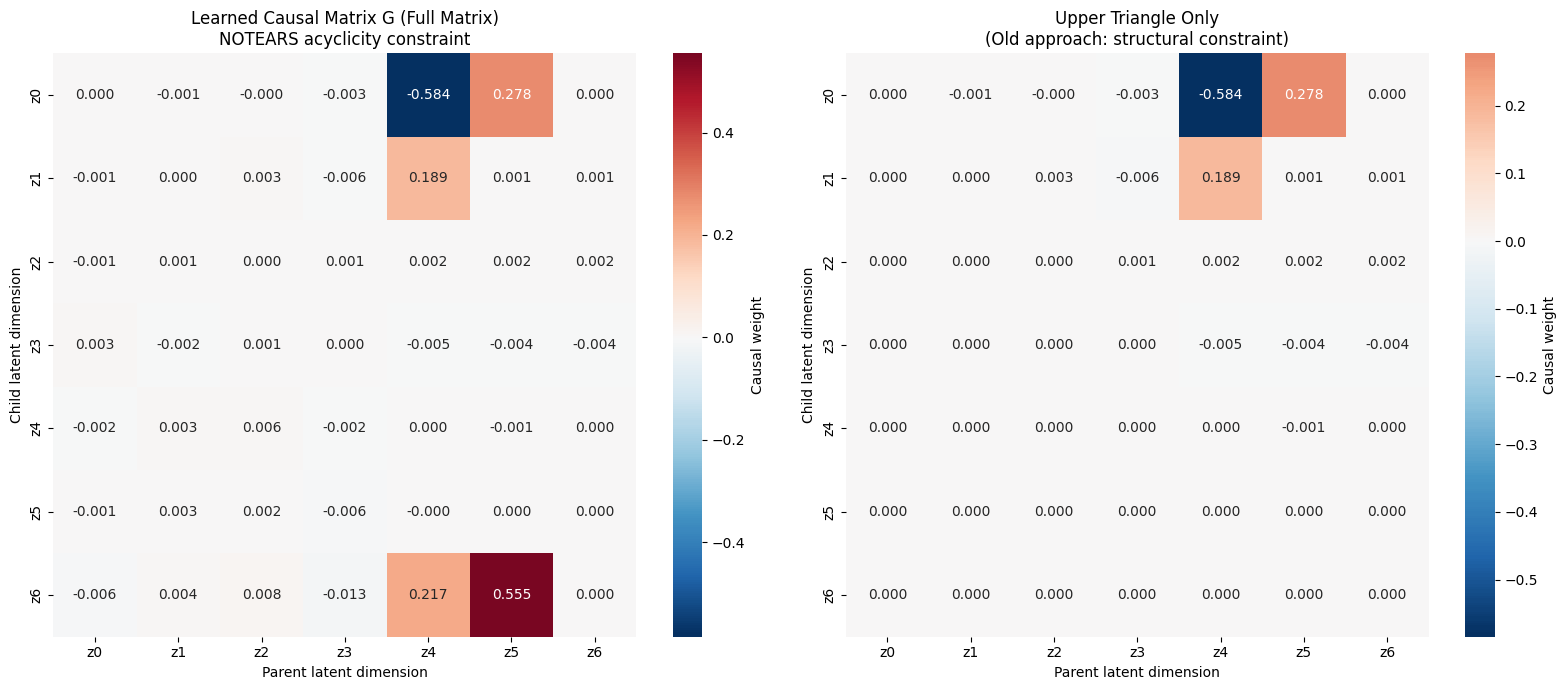


Causal Matrix G Statistics:
  Shape: (7, 7)

  Full Matrix (off-diagonal):
    Total possible edges: 49
    Non-zero edges (|w| > 0.01): 6
    Sparsity: 87.8%
    L1 norm: 1.9247

  Upper Triangle Only:
    Total possible edges: 49
    Non-zero edges (|w| > 0.01): 3
    Sparsity: 93.9%
    L1 norm: 1.0868

  DAG Check (spectral radius):
    Spectral radius: 0.0439
    Is DAG: ✓ Yes (should be < 1.0)

  Key Differences from Old Approach:
    - Old: G restricted to upper-triangular (structural constraint)
    - New: G is full matrix, acyclicity enforced via NOTEARS penalty
    - New: Model learns optimal causal ordering from data


In [26]:
# Inspect learned causal matrix G
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract causal matrix
G = model.G.detach().cpu().numpy()

# Plot heatmap of full learned G matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full matrix
sns.heatmap(G, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            xticklabels=[f'z{i}' for i in range(G.shape[1])],
            yticklabels=[f'z{i}' for i in range(G.shape[0])],
            cbar_kws={'label': 'Causal weight'},
            ax=axes[0])
axes[0].set_title('Learned Causal Matrix G (Full Matrix)\nNOTEARS acyclicity constraint')
axes[0].set_xlabel('Parent latent dimension')
axes[0].set_ylabel('Child latent dimension')

# Upper triangle only (for comparison with old approach)
G_upper = np.triu(G, k=1)
sns.heatmap(G_upper, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=[f'z{i}' for i in range(G.shape[1])],
            yticklabels=[f'z{i}' for i in range(G.shape[0])],
            cbar_kws={'label': 'Causal weight'},
            ax=axes[1])
axes[1].set_title('Upper Triangle Only\n(Old approach: structural constraint)')
axes[1].set_xlabel('Parent latent dimension')
axes[1].set_ylabel('Child latent dimension')

plt.tight_layout()
plt.savefig(cfg.outdir + '/causal_matrix_G.png', dpi=150)
plt.show()

# Compute sparsity statistics
G_offdiag = G - np.diag(np.diag(G))  # Remove diagonal
total_edges = G_offdiag.size
nonzero_edges_full = np.count_nonzero(np.abs(G_offdiag) > 0.01)  # threshold at 0.01
sparsity_pct_full = 100 * (1 - nonzero_edges_full / total_edges)

G_upper = np.triu(G, k=1)
upper_edges = G_upper.size
nonzero_edges_upper = np.count_nonzero(np.abs(G_upper) > 0.01)
sparsity_pct_upper = 100 * (1 - nonzero_edges_upper / upper_edges)

print(f"\nCausal Matrix G Statistics:")
print(f"  Shape: {G.shape}")
print(f"\n  Full Matrix (off-diagonal):")
print(f"    Total possible edges: {total_edges}")
print(f"    Non-zero edges (|w| > 0.01): {nonzero_edges_full}")
print(f"    Sparsity: {sparsity_pct_full:.1f}%")
print(f"    L1 norm: {np.abs(G_offdiag).sum():.4f}")
print(f"\n  Upper Triangle Only:")
print(f"    Total possible edges: {upper_edges}")
print(f"    Non-zero edges (|w| > 0.01): {nonzero_edges_upper}")
print(f"    Sparsity: {sparsity_pct_upper:.1f}%")
print(f"    L1 norm: {np.abs(G_upper).sum():.4f}")

# Check acyclicity (NOTEARS constraint)
def check_acyclicity(G):
    """Check if G defines a DAG using eigenvalues of G."""
    # Remove self-loops
    G_offdiag = G - np.diag(np.diag(G))
    # Compute spectral radius
    eigenvalues = np.linalg.eigvals(G_offdiag)
    spectral_radius = np.max(np.abs(eigenvalues))
    return spectral_radius < 1.0, spectral_radius

is_dag, spectral_radius = check_acyclicity(G)
print(f"\n  DAG Check (spectral radius):")
print(f"    Spectral radius: {spectral_radius:.4f}")
print(f"    Is DAG: {'✓ Yes' if is_dag else '✗ No'} (should be < 1.0)")

print(f"\n  Key Differences from Old Approach:")
print(f"    - Old: G restricted to upper-triangular (structural constraint)")
print(f"    - New: G is full matrix, acyclicity enforced via NOTEARS penalty")
print(f"    - New: Model learns optimal causal ordering from data")

In [27]:
# predictions
preds = model.predict(adata, seed=42)

/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PLEKHN1', 'HES4']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


In [28]:
preds

AnnData object with n_obs × n_vars = 1703 × 5000
    obs: 'set', 'cell_type', 'intervention', 'source_cell_idx'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'ensembl', 'kind', 'community'

## Visualization: Predicted vs Actual Interventions

Now let's create comprehensive UMAP visualizations to compare predicted and actual intervention effects.

In [30]:
# Visualize predictions vs actual using UMAP
from gcrl.evaluation import visualize_predictions

print("Creating UMAP visualizations...")
print(f"Predictions: {preds.n_obs:,} cells")
print(f"Test data: {adata[adata.obs['set'] == 'test'].n_obs:,} cells")
print(f"Training controls: {adata[(adata.obs['set'] == 'training') & (adata.obs['intervention'] == 'unperturbed')].n_obs:,} cells")

# ============================================================================
# UMAP FITTING STRATEGY: Choose how to fit the UMAP embedding
# ============================================================================
# Option 1: umap_fit_on="controls" (DEFAULT)
#   - Fits UMAP only on training control (unperturbed) cells
#   - Projects test and predicted cells onto this baseline space
#   - Pros: Consistent baseline, avoids data leakage, interpretable reference
#   - Use when: You want to see how perturbations deviate from baseline
#
# Option 2: umap_fit_on="all"
#   - Fits UMAP on all cells (controls + test + predictions)
#   - Shows global structure across all conditions
#   - Pros: Better global structure, shows relationships between all conditions
#   - Use when: You want to see overall relationships between conditions
# ============================================================================

# Create visualizations
visualize_predictions(
    adata=adata,
    preds=preds,
    output_dir=cfg.outdir + "/predictions_viz",
    
    # ===== CHOOSE YOUR UMAP FITTING STRATEGY HERE =====
    umap_fit_on="all",  # Options: "controls" (default) or "all"
    # ==================================================
    
    # UMAP parameters
    n_pcs=30,
    umap_n_neighbors=15,
    umap_min_dist=0.3,
    random_state=42
)

print("\n✅ Visualizations complete!")
print(f"   Check: {cfg.outdir}/predictions_viz/")
print("   - per_intervention/: Individual UMAPs for each (cell_type, intervention) pair")
print("   - per_celltype/: Aggregate UMAPs showing all interventions per cell type")

Creating UMAP visualizations...
Predictions: 1,703 cells
Test data: 1,703 cells
Training controls: 8,907 cells
gCRL-VAE Prediction Visualization

📊 Data Summary:
  Training controls: 8,907 cells
  Test data: 1,703 cells
  Predictions: 1,703 cells
  Cell types: ['K562']
  Test interventions: 6

🔧 Fitting UMAP on all cells (controls + test + predictions)...
   PCA: 5000 genes → 100 PCs (explained variance: 16.28%)


/home/laganiv/miniconda3/envs/deep_learning/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



📈 Creating per-intervention plots...
   Generating 6 plots...


/home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/src/gcrl/evaluation/prediction_viz.py:337: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_groups = test_data.obs.groupby([cell_type_key, intervention_key])


   ✓ 6 plots saved to per_intervention/

📈 Creating per-cell-type plots...
   Generating 1 plots...
   ✓ 1 plots saved to per_celltype/

✅ Visualization complete!
   Plots saved to: /home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/notebooks/20_modeling_gcrl_vae/../../results/real/Norman2019/VAE/predictions_viz

✅ Visualizations complete!
   Check: ../../results/real/Norman2019/VAE/predictions_viz/
   - per_intervention/: Individual UMAPs for each (cell_type, intervention) pair
   - per_celltype/: Aggregate UMAPs showing all interventions per cell type


## Quantitative Evaluation Metrics

Compute performance metrics comparing predicted vs actual intervention effects.

In [32]:
# Compute and save performance metrics
from gcrl.evaluation.prediction_eval import evaluate_predictions
import os

# Create performance metrics directory
performance_dir = os.path.join(cfg.outdir, "performances")
os.makedirs(performance_dir, exist_ok=True)

print("Computing performance metrics...")
print(f"Results will be saved to: {performance_dir}")

# Compute metrics comparing predictions to actual test data
metrics_df = evaluate_predictions(
    adata=adata,
    preds=preds,
    output_dir=performance_dir,
    set_key='set',
    intervention_key='intervention',
    cell_type_key='cell_type',
    control_labels=('control', 'unperturbed')
)

# Display top 10 best predictions (lowest centroid distance)
print("\n🏆 Top 10 Best Predictions (lowest centroid distance):")
print("=" * 70)
print(metrics_df.head(10).to_string(index=False))

# Display bottom 10 predictions (highest centroid distance)
print("\n⚠️  Bottom 10 Predictions (highest centroid distance):")
print("=" * 70)
print(metrics_df.tail(10).to_string(index=False))

print(f"\n✅ Performance metrics saved to: {performance_dir}")
print(f"   - prediction_metrics.csv: Overall metrics for all interventions")
print(f"   - <cell_type>_metrics.csv: Per-cell-type breakdowns")

Computing performance metrics...
Results will be saved to: ../../results/real/Norman2019/VAE/performances
gCRL-VAE Prediction Evaluation

📊 Data Summary:
  Test data: 1,703 cells
  Predictions: 1,703 cells
  Training controls: 8,907 cells
  Cell types: ['K562']
  Test interventions: 6

📈 Computing metrics...
  - centroid_distance: Model prediction vs. actual
  - baseline_worst_case: Control centroid vs. actual (no prediction)
  - baseline_perfect: Random split of actual cells (perfect prediction)


/home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/src/gcrl/evaluation/prediction_eval.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_coords_expr = np.asarray(preds[pred_mask].X)



💾 Overall metrics saved to: ../../results/real/Norman2019/VAE/performances/prediction_metrics.csv

💾 Per-cell-type metrics:
   K562: K562_metrics.csv

📊 Summary Statistics:
  Total interventions evaluated: 6

  Model Prediction (centroid_distance):
    Mean: 11.5457
    Median: 11.0877
    Min: 9.0437
    Max: 16.4046

  Worst Case Baseline (control as prediction):
    Mean: 12.6728
    Median: 12.4609
    Min: 8.4787
    Max: 17.9664

  Perfect Baseline (random split of actual):
    Mean: 5.2761
    Median: 5.1660
    Min: 3.0332
    Max: 7.7779

  Relative Performance:
    Improvement over worst case: 8.0% (mean)
    Gap to perfect baseline: 131.2% (mean)

✅ Evaluation complete!
   Metrics saved to: /home/laganiv/Desktop/projects/CausalEmbed/grn_crl/gCAL/gCRL/notebooks/20_modeling_gcrl_vae/../../results/real/Norman2019/VAE/performances

🏆 Top 10 Best Predictions (lowest centroid distance):
cell_type intervention  centroid_distance  baseline_worst_case  baseline_perfect  n_test_cells

Norman: still working on the gene selection

Norman: think using the clustering method used in Salt and Peper

Decide metrics (test set definition and performance metrics depends upon it)

Swapping MMD and centroid

Options for all communities
